DIABETES PATIENTS ANALYSIS: TRANSFORMATION, ANALYSIS AND INSIGHTS

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
## Dataset upload
df = pd.read_csv("diabetes.csv")
print (df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [128]:
## Dataset basic exploratory phase
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [129]:
summary = df.describe()
print (summary)

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

DATA CLEANING PHASE

In [130]:

## Even though the exploratory phase shows there's non-null row, just to double check.
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [131]:
## In the exploratory phase, there are some values in zero  which are medically not accurate for some criteria
## It could mean there are some missing values, so it's needed to identify them

(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [132]:
## As the values are medically inaccurate, they will become null in order to better manage those values
values_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[values_to_fix] = df[values_to_fix].replace(0, np.nan)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


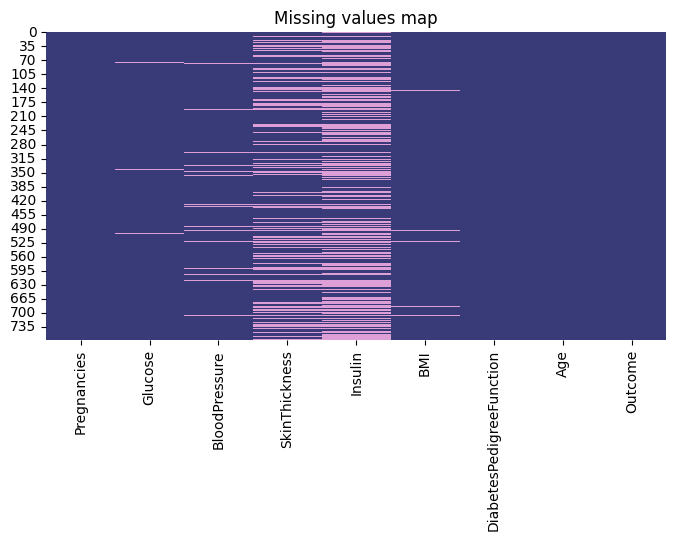

In [133]:
## To better identify them, let's visualize the data
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='tab20b')
plt.title("Missing values map")
plt.show()

In [134]:
## In order to clean these non-sense data, values are filled with the median 

for col in values_to_fix:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


STATISTICAL ANALYSIS

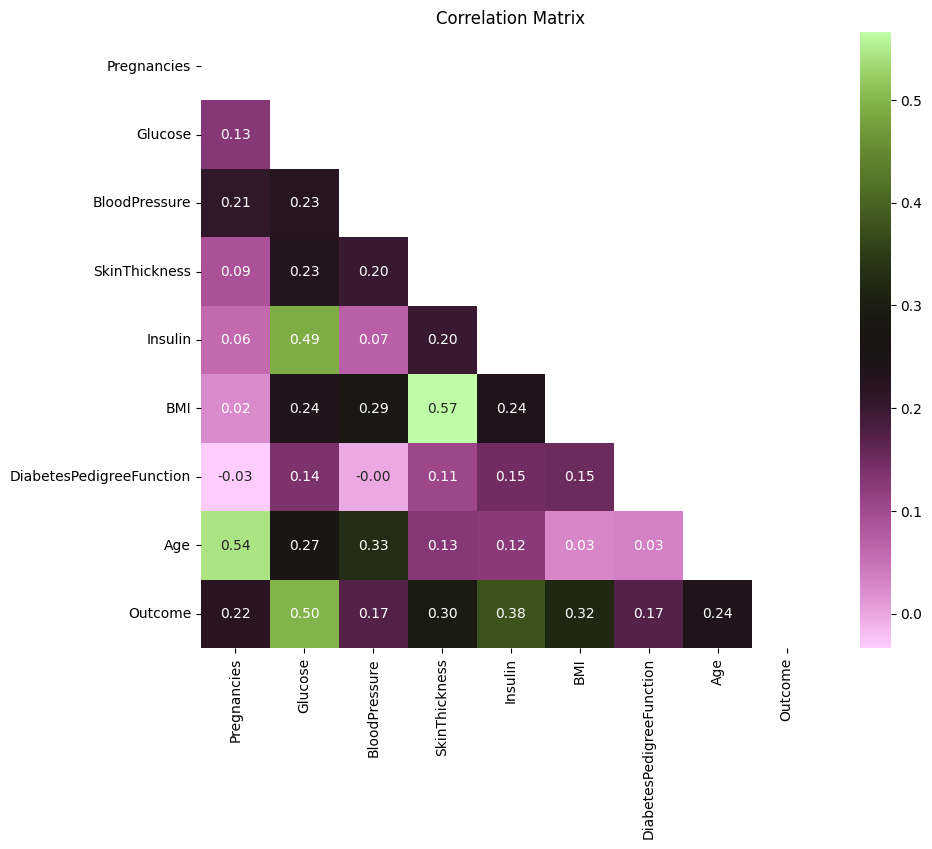

In [135]:
##Correlation between criteria

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool)) 
sns.heatmap(df.corr(), mask=mask, annot=True, cmap='vanimo', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

C:\Users\natam\AppData\Local\Temp\ipykernel_2204\3084894366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Outcome', y='Glucose', data=df, ax=axes[0,0], palette="rocket")
C:\Users\natam\AppData\Local\Temp\ipykernel_2204\3084894366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Outcome', y='BMI', data=df, ax=axes[0,1], palette="rocket")
C:\Users\natam\AppData\Local\Temp\ipykernel_2204\3084894366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Outcome', y='Insulin', data=df, ax=axes[1, 0], palette="rocket")
C:\Use

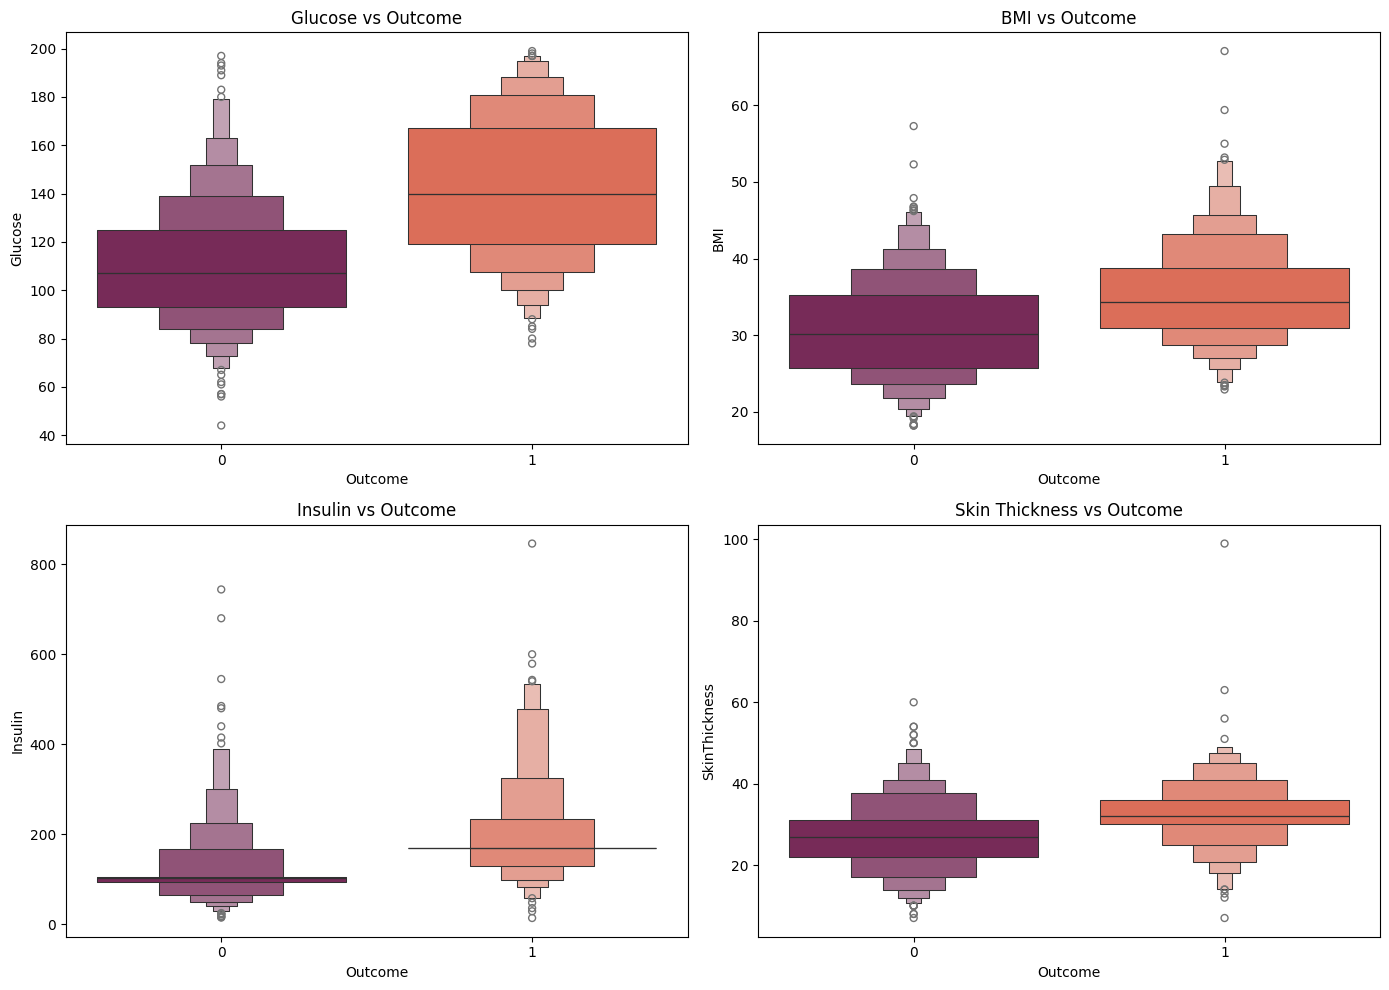

In [136]:
##Boxenplot analysis between the four criteria more correlated and the outcome 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxenplot(x='Outcome', y='Glucose', data=df, ax=axes[0,0], palette="rocket")
axes[0,0].set_title('Glucose vs Outcome')

sns.boxenplot(x='Outcome', y='BMI', data=df, ax=axes[0,1], palette="rocket")
axes[0,1].set_title('BMI vs Outcome')

sns.boxenplot(x='Outcome', y='Insulin', data=df, ax=axes[1, 0], palette="rocket")
axes[1, 0].set_title('Insulin vs Outcome')

sns.boxenplot(x='Outcome', y='SkinThickness', data=df, ax=axes[1, 1], palette="rocket")
axes[1, 1].set_title('Skin Thickness vs Outcome')

plt.tight_layout()
plt.show()

In [137]:
##Verify importance of the criteria comparing std and mean
print(pd.DataFrame({
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}, index=X.columns).sort_values('importance_mean', ascending=False))

                          importance_mean  importance_std
Insulin                          0.195455        0.029322
Age                              0.020455        0.009015
SkinThickness                    0.012013        0.011110
Glucose                          0.010714        0.011299
Pregnancies                      0.008442        0.006526
BMI                              0.002273        0.009907
DiabetesPedigreeFunction        -0.000974        0.010117
BloodPressure                   -0.008766        0.006582


PIPELINE DESIGN PHASE

In [138]:
##Libraries for pipeline design
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

In [139]:
##Split the outcome from the evaluated criteria
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [140]:
##Create variables for test values and train values
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [141]:
## Define pipeline for logistic regression and random forest model, also auto-scale for values

pipe_lr = Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression())])
pipe_rf = Pipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

## Train and evaluate the designed model
models = {'Logistic Regression': pipe_lr, 'Random Forest': pipe_rf}

for name, m in models.items():
    m.fit(x_train, y_train)
    score = m.score(x_test, y_test)
    print(f"Model: {name} | Accuracy: {score:.2f}")
    print(classification_report(y_test, m.predict(x_test)))
    print("-" * 60)

Model: Logistic Regression | Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154

------------------------------------------------------------
Model: Random Forest | Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       100
           1       0.79      0.85      0.82        54

    accuracy                           0.87       154
   macro avg       0.85      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154

------------------------------------------------------------


In [142]:
from sklearn.inspection import permutation_importance

In [143]:
## Permutation importance for the pipeline of the random forest
model = pipe_rf

x_test_scaled_df = pd.DataFrame(
    model.named_steps['scaler'].transform(X_test),
    columns=x.columns
)

result = permutation_importance(
    model, x_test, y_test, n_repeats=20, random_state=42, scoring='accuracy'
)
importance_permutation = pd.Series(
    result.importances_mean, index=x.columns
).sort_values(ascending=False)
print("Permutation importance:")
print(importance_permutation)

Permutation importance:
Insulin                     0.195455
Age                         0.020455
SkinThickness               0.012013
Glucose                     0.010714
Pregnancies                 0.008442
BMI                         0.002273
DiabetesPedigreeFunction   -0.000974
BloodPressure              -0.008766
dtype: float64


SHAP IMPLEMENTATION

In [144]:
import shap

explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_scaled_df)
print(type(shap_values))
##Verify dimensions and object
if isinstance(shap_values, list):
    print("List, lenght:", len(shap_values))
    print("Element shape:", shap_values[0].shape)
else:
    print("Array, shape:", shap_values.shape)


<class 'numpy.ndarray'>
Array, shape: (154, 8, 2)


In [145]:
## Create if cicle to create the classification taking in count the object and dimensions
if isinstance(shap_values, list):
    final_shap_values = shap_values[1]
elif shap_values.ndim == 3:
    final_shap_values = shap_values[:, :, 1]   
else:
    final_shap_values = shap_values


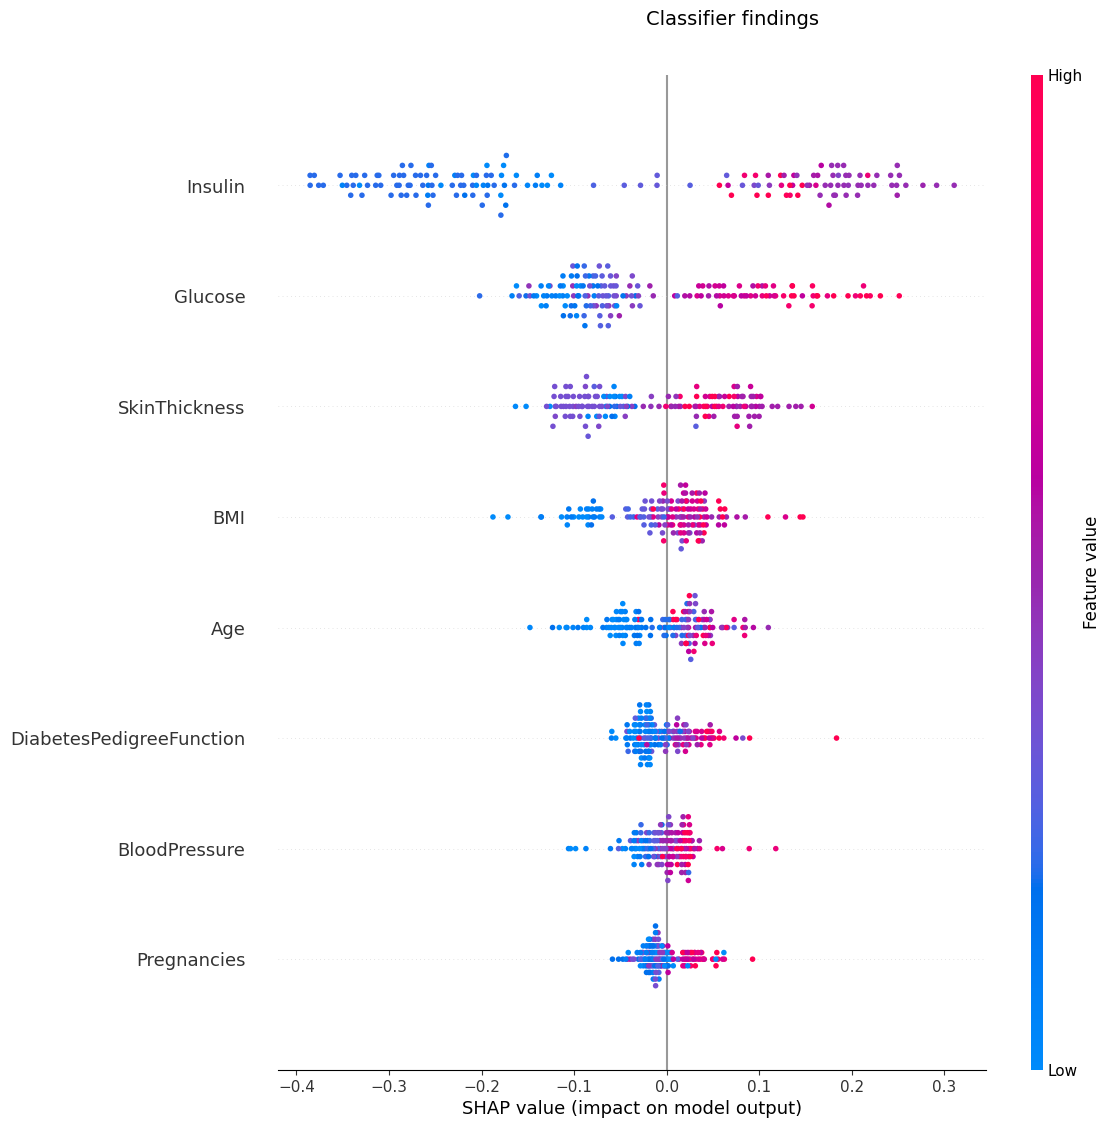

In [146]:
##Graphic SHAP findings
shap.summary_plot(final_shap_values, X_test_scaled_df, show=False)
fig = plt.gcf()
fig.set_size_inches(13, 13)
fig.suptitle("Classifier findings", fontsize=14, y=0.95, x=0.65, ha='center')
plt.subplots_adjust(left=0.3, top=0.9)
plt.show()


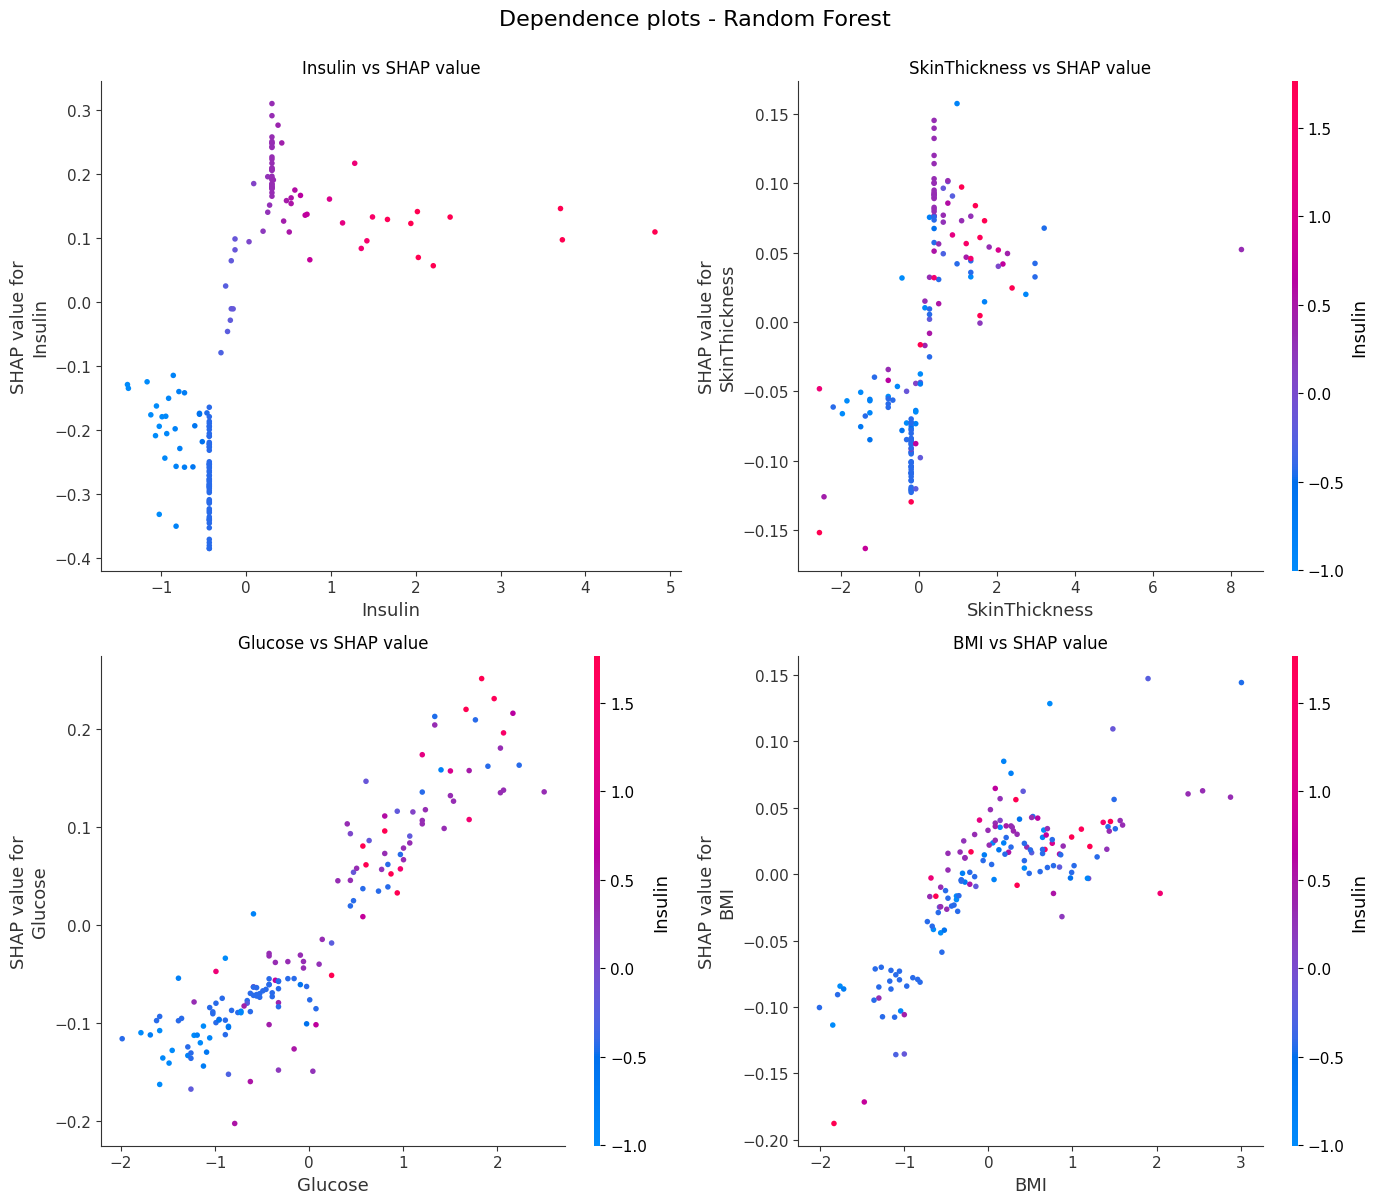

In [ ]:
##Dependence plots for the most important criteria found in SHAP classifier
main_variables = ["Insulin", "SkinThickness", "Glucose", "BMI"]
variable_color = "Insulin"

n_vars = len(main_variables)
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()  

for i, var in enumerate(main_variables):
    shap.dependence_plot(
        var,
        final_shap_values,
        X_test_scaled_df,
        interaction_index=variable_color,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"{var} vs SHAP value")


fig.suptitle("Dependence plots - Random Forest", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

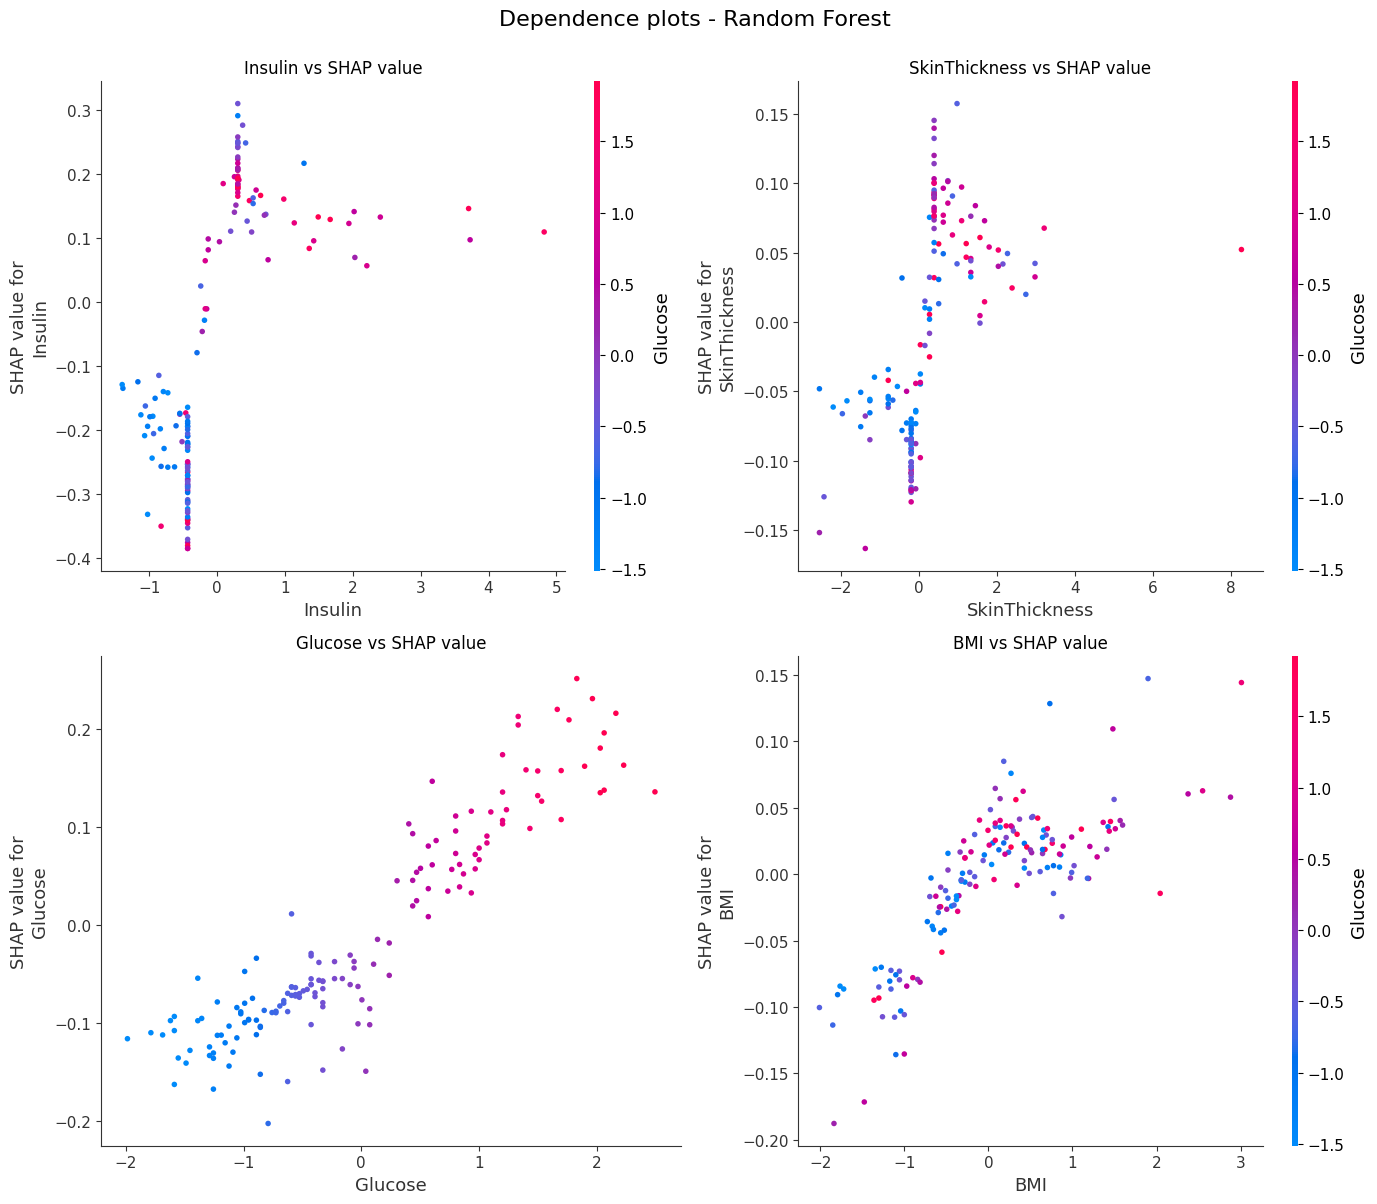

In [171]:
variable_color = "Glucose"

n_vars = len(main_variables)
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()  

for i, var in enumerate(main_variables):
    shap.dependence_plot(
        var,
        final_shap_values,
        X_test_scaled_df,
        interaction_index=variable_color,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"{var} vs SHAP value")


fig.suptitle("Dependence plots - Random Forest", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()